# Code Example of Gradient Descent

In [195]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.datasets import make_regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [196]:
X, y = make_regression(n_features=1, n_targets=1, n_informative=1, noise=80, n_samples=4, random_state=42)

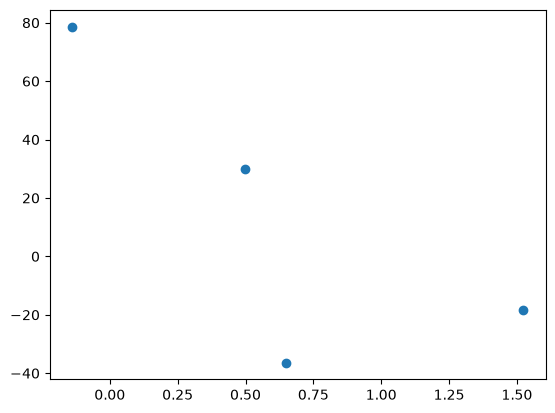

In [197]:
plt.scatter(X, y)

In [198]:
lr = LinearRegression()
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-57.99]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,50.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.19]


In [199]:
lr.coef_

array([-57.99225681])

In [200]:
lr.intercept_

np.float64(50.20315110942307)

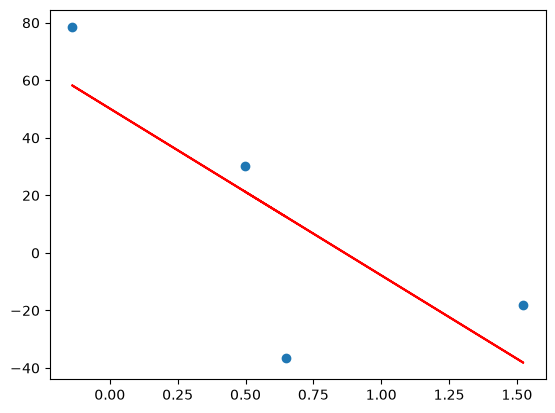

In [201]:
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color='red')

### Applying gradient descent -- taking m = -57.992 constant, we will operate on b(intercept)

- Taking b(initial guess) = 100

In [202]:
y_pred = (-57.992*X + 100).reshape(4)
y_pred

array([ 62.4392463 , 108.01822335,  11.67645257,  71.19455284])

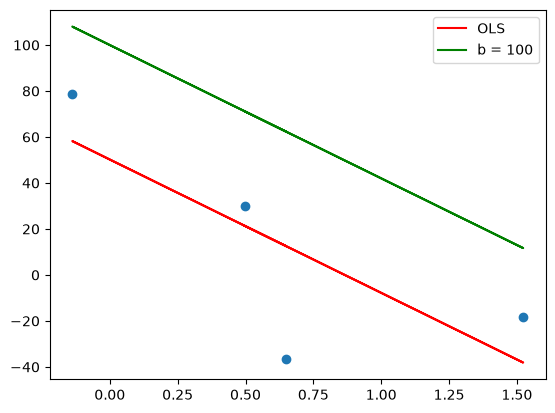

In [203]:
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color = 'red', label = 'OLS') #OLS = Ordinary Least Squares
plt.plot(X, y_pred, color = 'green', label = "b = 100")
plt.legend()
plt.show()

In [204]:
# Finding loss slope and step size --

m = -57.992
b = 100
learning_rate = 0.1

loss_slope = -2*np.sum(y - m*X.ravel() - b)

step_size = learning_rate*loss_slope
step_size

np.float64(39.83760901375814)

In [205]:
# Finding new b - b1 from b0(initial guess)

b = b - step_size
b

np.float64(60.16239098624186)

In [206]:
y_pred1 = (m*X + b).reshape(4)
y_pred1

array([ 22.60163728,  68.18061434, -28.16115645,  31.35694382])

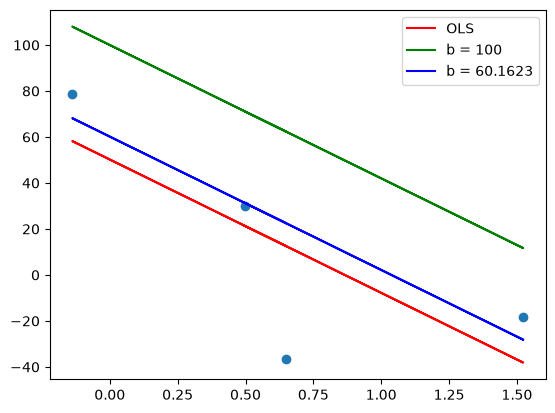

In [207]:
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color = 'red', label = 'OLS') #OLS = Ordinary Least Squares
plt.plot(X, y_pred, color = 'green', label = "b = 100")
plt.plot(X, y_pred1, color = 'blue', label = 'b = 60.1623')
plt.legend()
plt.show()

In [208]:
# Similarly.. as we keep iterating the best fit line and b converges to the best fit line by OLS with many iterations ..

In [209]:
# Iteration-2

loss_slope = -2*np.sum(y - m*X.ravel() - b)
step_size = learning_rate*loss_slope
step_size

np.float64(7.967521802751624)

In [210]:
b = b - step_size
b

np.float64(52.19486918349023)

In [211]:
y_pred2 = (m*X + b).reshape(4)
y_pred2

array([ 14.63411548,  60.21309254, -36.12867825,  23.38942202])

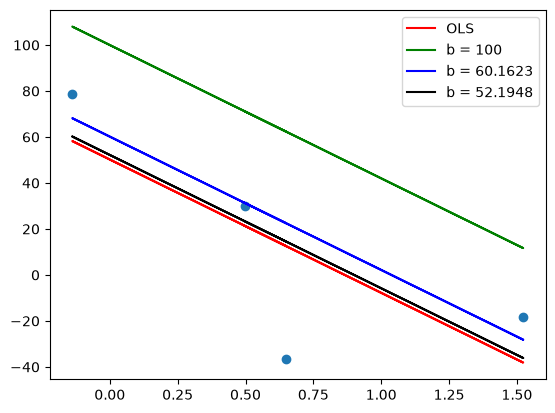

In [212]:
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color = 'red', label = 'OLS') #OLS = Ordinary Least Squares
plt.plot(X, y_pred, color = 'green', label = "b = 100")
plt.plot(X, y_pred1, color = 'blue', label = 'b = 60.1623')
plt.plot(X, y_pred2, color = 'black', label = 'b = 52.1948')
plt.legend()
plt.show()

In [213]:
# Iteration-3

loss_slope = -2*np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(15.935043605503225)

In [214]:
step_size = learning_rate*loss_slope
step_size

np.float64(1.5935043605503225)

In [215]:
b = b - step_size
b

np.float64(50.601364822939914)

In [216]:
y_pred3 = (m*X + b).reshape(4)

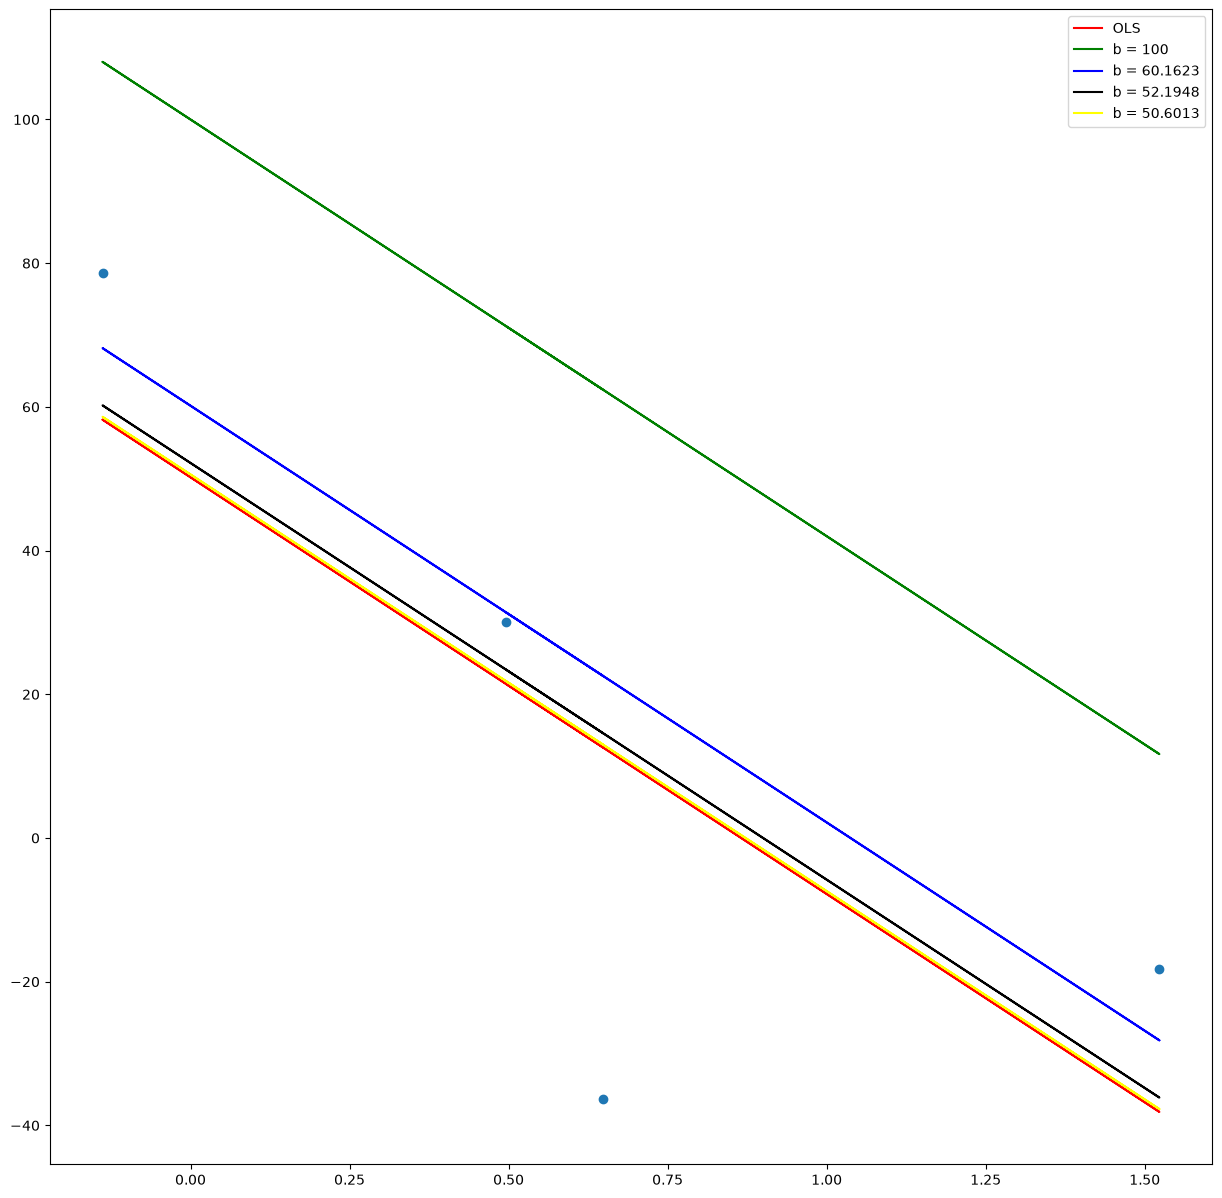

In [217]:
plt.figure(figsize=(15, 15))
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color = 'red', label = 'OLS') #OLS = Ordinary Least Squares
plt.plot(X, y_pred, color = 'green', label = "b = 100")
plt.plot(X, y_pred1, color = 'blue', label = 'b = 60.1623')
plt.plot(X, y_pred2, color = 'black', label = 'b = 52.1948')
plt.plot(X, y_pred3, color = 'yellow', label = "b = 50.6013")
plt.legend()
plt.show()

### After 3 iterations, the result almost converges to the result by ordinary least square method
### If learning rate = 0.01 instead of 0.1, more iterations required, converging occurs slowly

# Applying a Loop for performing 100 iterations(epochs) --

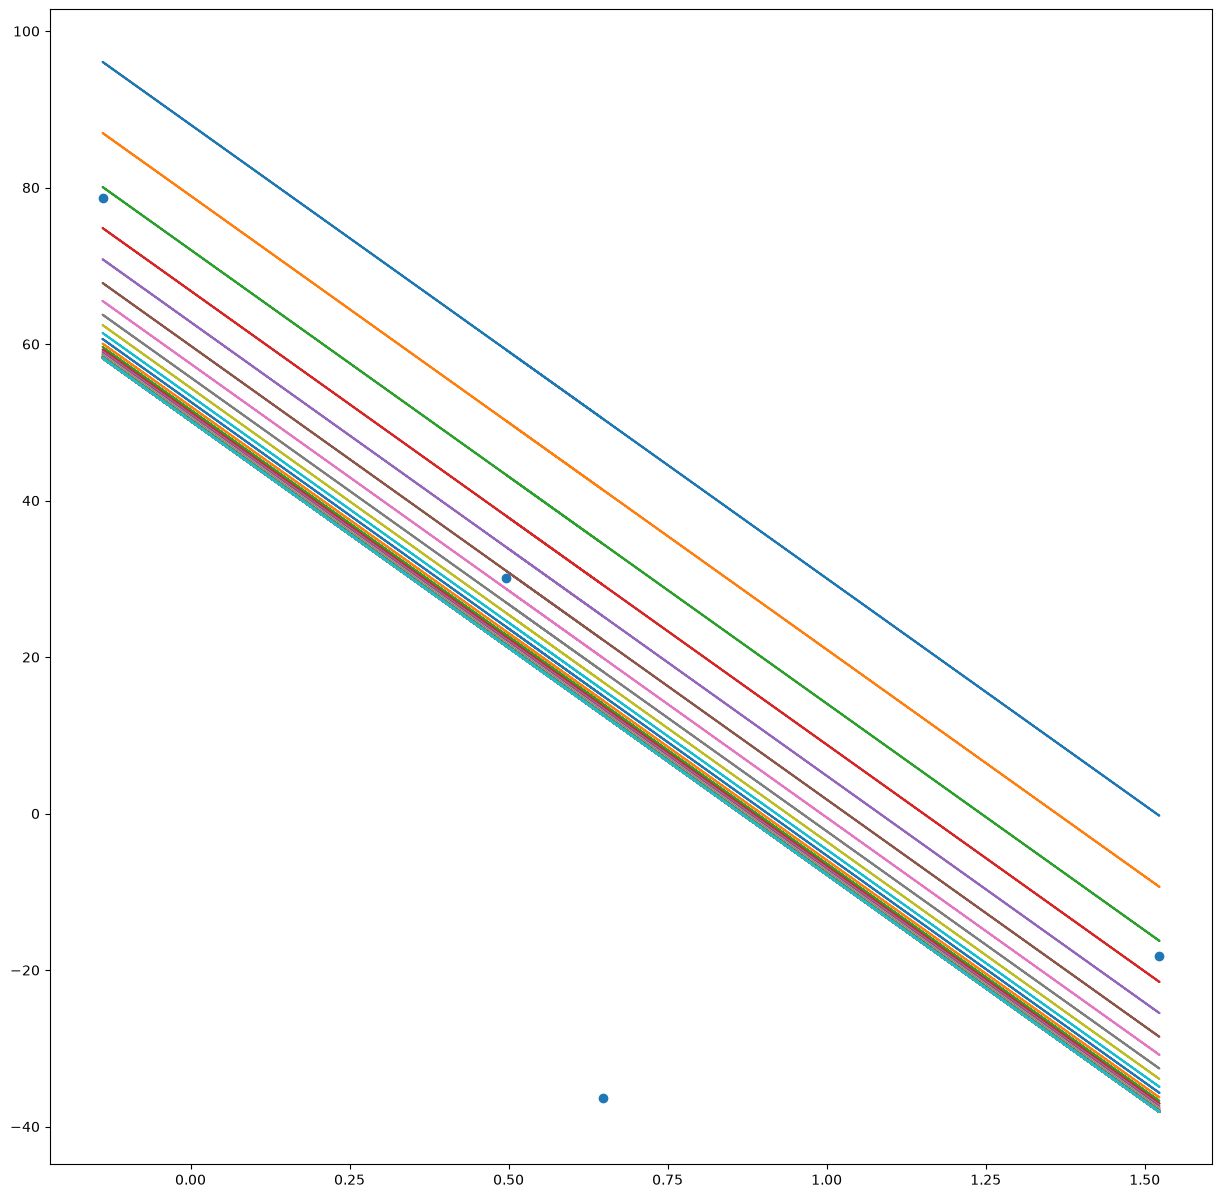

In [218]:
b = 100
m = -57.992
learning_rate = 0.03

epochs = 100

plt.figure(figsize=(15, 15))

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (learning_rate * loss_slope)

  y_pred = m * X + b

  plt.plot(X,y_pred)

plt.scatter(X,y)

In [219]:
# As we manipulate the learning rate in the for loop, convergence rate changes!

In [220]:
# done :)